In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
from tqdm import tqdm
from typing import Union

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from sklearn.metrics import mean_absolute_percentage_error

data = pd.read_csv("../powerconsumption.csv")
data["Datetime"] = pd.to_datetime(data["Datetime"])
data = data.sort_values("Datetime").set_index("Datetime")

series = data["PowerConsumption_Zone1"].dropna()
print(f"Shape: {series.shape}")
print(f"Period: {series.index.min()} → {series.index.max()}")
series.head()

Shape: (52416,)
Period: 2017-01-01 00:00:00 → 2017-12-30 23:50:00


Datetime
2017-01-01 00:00:00    34055.69620
2017-01-01 00:10:00    29814.68354
2017-01-01 00:20:00    29128.10127
2017-01-01 00:30:00    28228.86076
2017-01-01 00:40:00    27335.69620
Name: PowerConsumption_Zone1, dtype: float64

In [10]:
TESTTIMESTEPS = 1008   #1 week of 10 minutes data
SEASONAL_M    = 144    #daily cycle in 10 minutes data

train = series.iloc[:-TESTTIMESTEPS]
test  = series.iloc[-TESTTIMESTEPS:]

print(f"Train: {len(train):,} obs  ({len(train)/SEASONAL_M:.0f} days)")
print(f"Test: {len(test):,} obs  ({len(test)/SEASONAL_M:.0f} days)")
print(f"Train range: {train.index.min()} → {train.index.max()}")
print(f"Test range: {test.index.min()}  → {test.index.max()}")

Train: 51,408 obs  (357 days)
Test: 1,008 obs  (7 days)
Train range: 2017-01-01 00:00:00 → 2017-12-23 23:50:00
Test range: 2017-12-24 00:00:00  → 2017-12-30 23:50:00


Stationarity

In [11]:
def adf_print(s, label):
    res = adfuller(s.dropna())
    print(f"{label:25s}  ADF = {res[0]:8.3f}   p-value = {res[1]:.3e}")

adf_print(train, "Raw (d = 0)")
adf_print(train.diff(), "1st difference (d = 1)")

Raw (d = 0)                ADF =  -31.877   p-value = 0.000e+00
1st difference (d = 1)     ADF =  -39.670   p-value = 0.000e+00


ACF and PACF

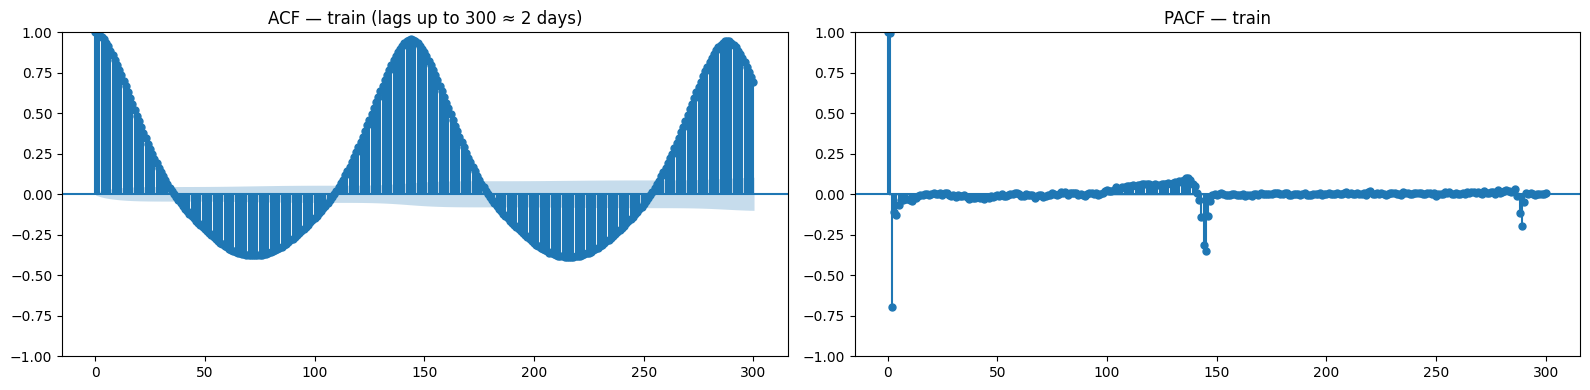

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf( train, lags=300, ax=axes[0])
plot_pacf(train, lags=300, ax=axes[1], method="ywm")
axes[0].set_title("ACF — train (lags up to 300 ≈ 2 days)")
axes[1].set_title("PACF — train")
plt.tight_layout()
plt.show()

GridSearch

In [6]:
import warnings
warnings.filterwarnings("ignore")
def optimize_ARIMA(endog: Union[pd.Series, list],
                   p_range, q_range, d) -> pd.DataFrame:
    rows = []
    for p, q in tqdm(list(product(p_range, q_range))):
        try:
            model = SARIMAX(endog, order=(p, d, q),
                            simple_differencing=False).fit(disp=False)
            rows.append([(p, d, q), model.aic])
        except Exception:
            continue
    out = pd.DataFrame(rows, columns=["(p,d,q)", "AIC"])
    return out.sort_values("AIC").reset_index(drop=True)

ps = range(0, 4)
qs = range(0, 4)

print(">>> ARIMA grid with d = 1")
grid_d1 = optimize_ARIMA(train, ps, qs, d=1)
grid_d1.head(10)

>>> ARIMA grid with d = 1


100%|██████████| 16/16 [01:07<00:00,  4.24s/it]


,"(p,d,q)",AIC
0,"(2, 1, 3)",774755.375694
1,"(1, 1, 2)",774756.217381
2,"(3, 1, 1)",774756.302696
3,"(1, 1, 3)",774757.101075
4,"(2, 1, 2)",774757.231357
5,"(3, 1, 3)",774757.448895
6,"(3, 1, 2)",774757.601392
7,"(2, 1, 1)",774854.099867
8,"(3, 1, 0)",774902.679268
9,"(1, 1, 1)",775315.848146


In [8]:
best_order_1 = grid_d1.iloc[0]["(p,d,q)"]
best_order_2 = (2, 1, 2) 

print(f"Combination 1 (best AIC): ARIMA{best_order_1}")
print(f"Combination 2: ARIMA{best_order_2}")

Combination 1 (best AIC): ARIMA(2, 1, 3)
Combination 2: ARIMA(2, 1, 2)


Even though we tested d = 1, the ADF test confirmed the original data is already fully stationary (p-value = 0.0). To avoid adding unnecessary mathematical noise (over-differencing), the correct approach is to run the grid search keeping d = 0

In [18]:
print(">>> ARIMA grid with d = 0 (Avoiding over-differencing)")

grid_d0 = optimize_ARIMA(train, ps, qs, d=0)

grid_d0.head(10)

>>> ARIMA grid with d = 0 (Avoiding over-differencing)


100%|██████████| 16/16 [01:10<00:00,  4.43s/it]


,"(p,d,q)",AIC
0,"(3, 0, 3)",774441.798292
1,"(2, 0, 2)",774442.291028
2,"(2, 0, 3)",774442.521577
3,"(3, 0, 2)",774442.668742
4,"(2, 0, 1)",775020.999802
5,"(3, 0, 0)",775250.681999
6,"(3, 0, 1)",775743.546724
7,"(2, 0, 0)",775743.949755
8,"(1, 0, 3)",779034.014695
9,"(1, 0, 2)",781650.808877


In [22]:
best_order_1_d0 = grid_d0.iloc[0]["(p,d,q)"]

best_order_2_d0 = grid_d0.iloc[1]["(p,d,q)"] 

print(f"Combination 1 (best AIC): ARIMA{best_order_1_d0}")
print(f"Combination 2 (2nd best): ARIMA{best_order_2_d0}")

Combination 1 (best AIC): ARIMA(3, 0, 3)
Combination 2 (2nd best): ARIMA(2, 0, 2)


Residual analysis


=== Combination 1 — ARIMA(2, 1, 3) ===
AIC = 774755.38


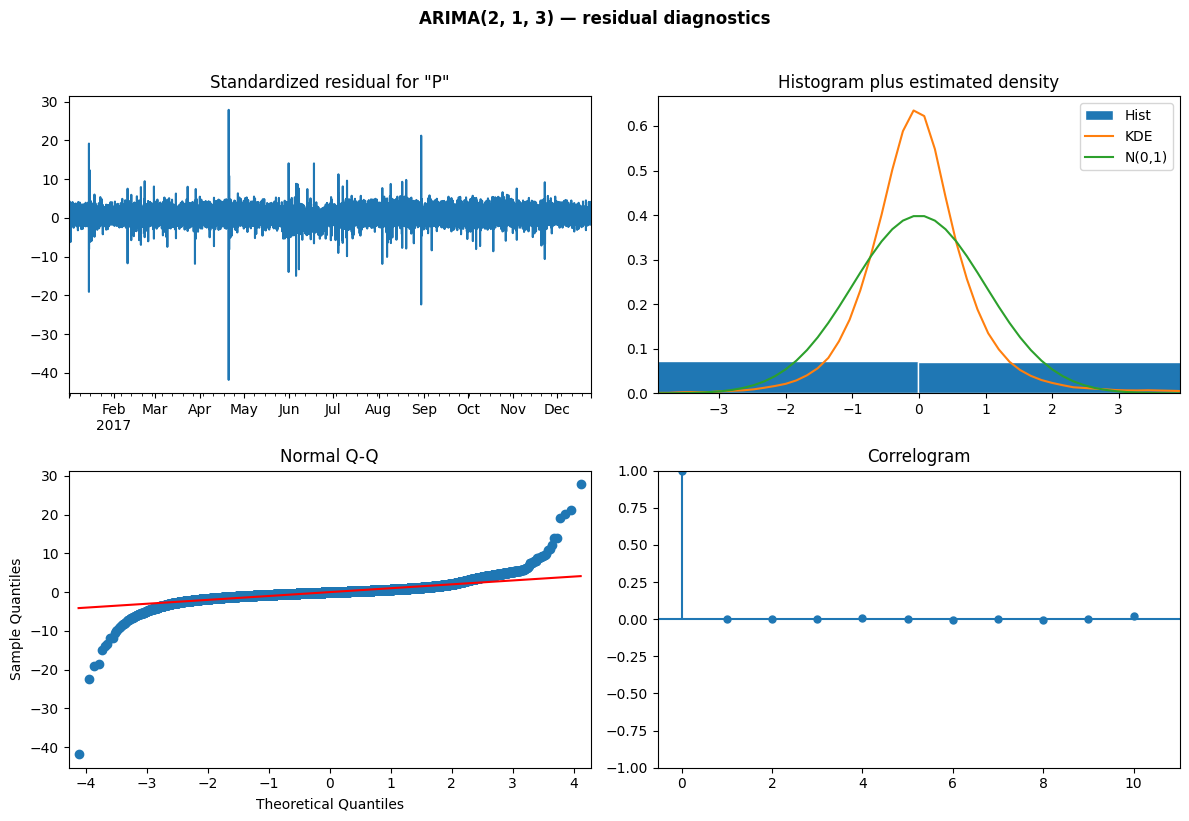

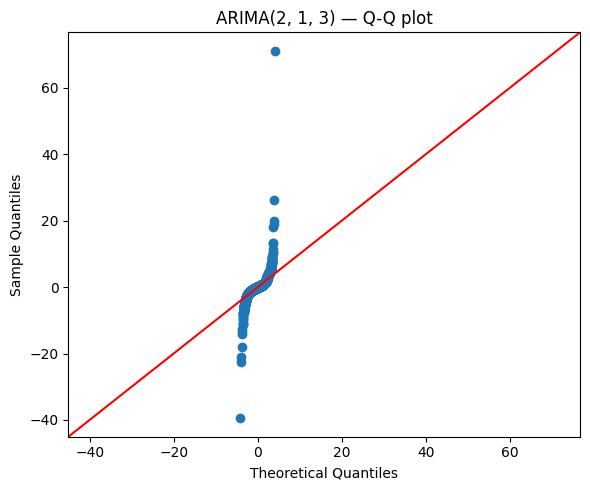

Ljung–Box test on residuals:
       lb_stat  lb_pvalue
10     68.4164        0.0
20    100.4670        0.0
30    308.4522        0.0
50    445.6232        0.0
144  9081.5088        0.0


In [12]:
def fit_and_diagnose(endog, order, label):
    model = SARIMAX(endog, order=order, simple_differencing=False).fit(disp=False)
    print(f"\n=== {label} — ARIMA{order} ===")
    print(f"AIC = {model.aic:.2f}")

    #4-panel diagnostics
    model.plot_diagnostics(figsize=(12, 8))
    plt.suptitle(f"ARIMA{order} — residual diagnostics", y=1.02, fontweight="bold")
    plt.tight_layout(); plt.show()

    #Q-Q plot 
    fig = qqplot(model.resid, line="45", fit=True)
    fig.set_size_inches(6, 5)
    plt.title(f"ARIMA{order} — Q-Q plot")
    plt.tight_layout(); plt.show()

    #Ljung–Box 
    lb = acorr_ljungbox(model.resid, lags=[10, 20, 30, 50, 144], return_df=True)
    print("Ljung–Box test on residuals:")
    print(lb.round(4))
    return model

model_1 = fit_and_diagnose(train, best_order_1, "Combination 1")


=== Combination 2 — ARIMA(2, 1, 2) ===
AIC = 774757.23


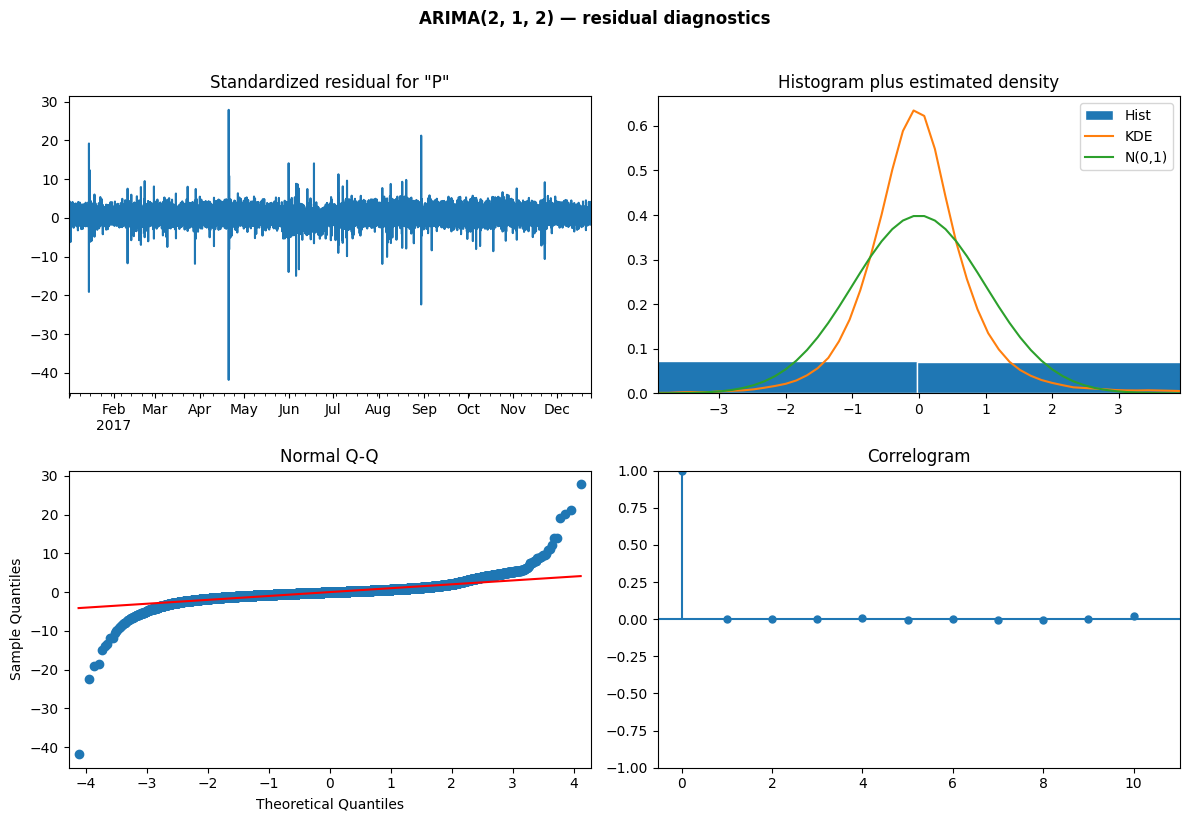

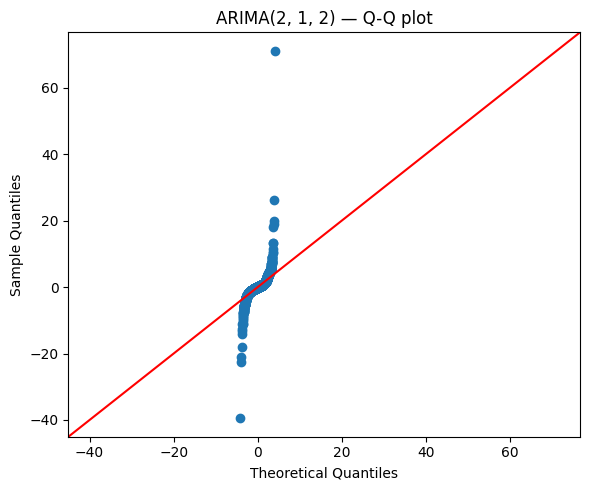

Ljung–Box test on residuals:
       lb_stat  lb_pvalue
10     71.1739        0.0
20    102.7404        0.0
30    311.4449        0.0
50    448.3097        0.0
144  9084.0358        0.0


In [13]:
model_2 = fit_and_diagnose(train, best_order_2, "Combination 2")

d = 0


=== Combination 1 — ARIMA(3, 0, 3) ===
AIC = 774441.80


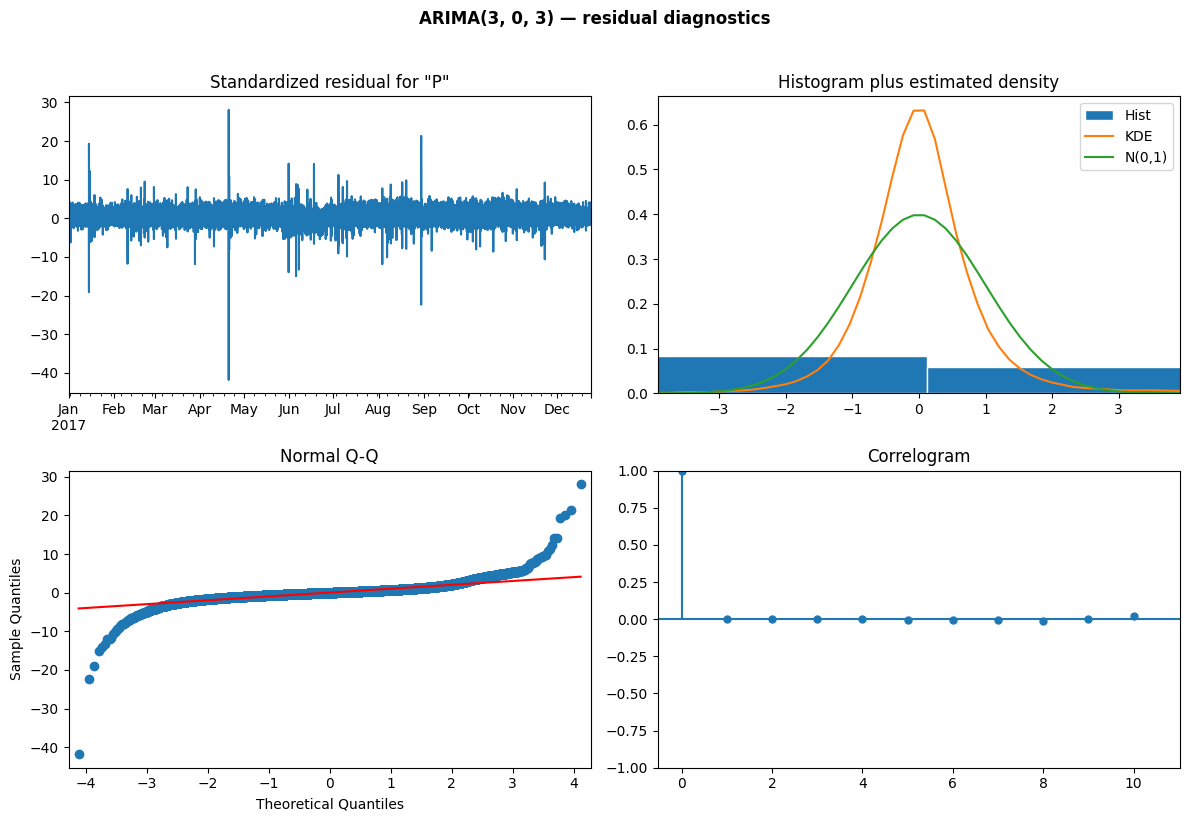

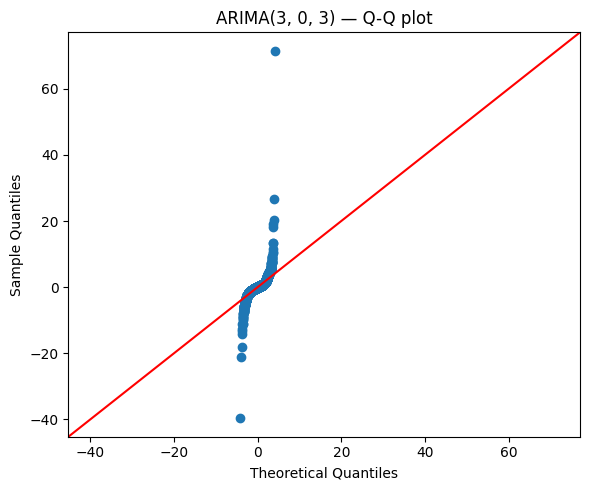

Ljung–Box test on residuals:
       lb_stat  lb_pvalue
10     37.0311     0.0001
20     65.5253     0.0000
30    261.9818     0.0000
50    390.7335     0.0000
144  8930.7792     0.0000

=== Combination 2 — ARIMA(2, 0, 2) ===
AIC = 774442.29


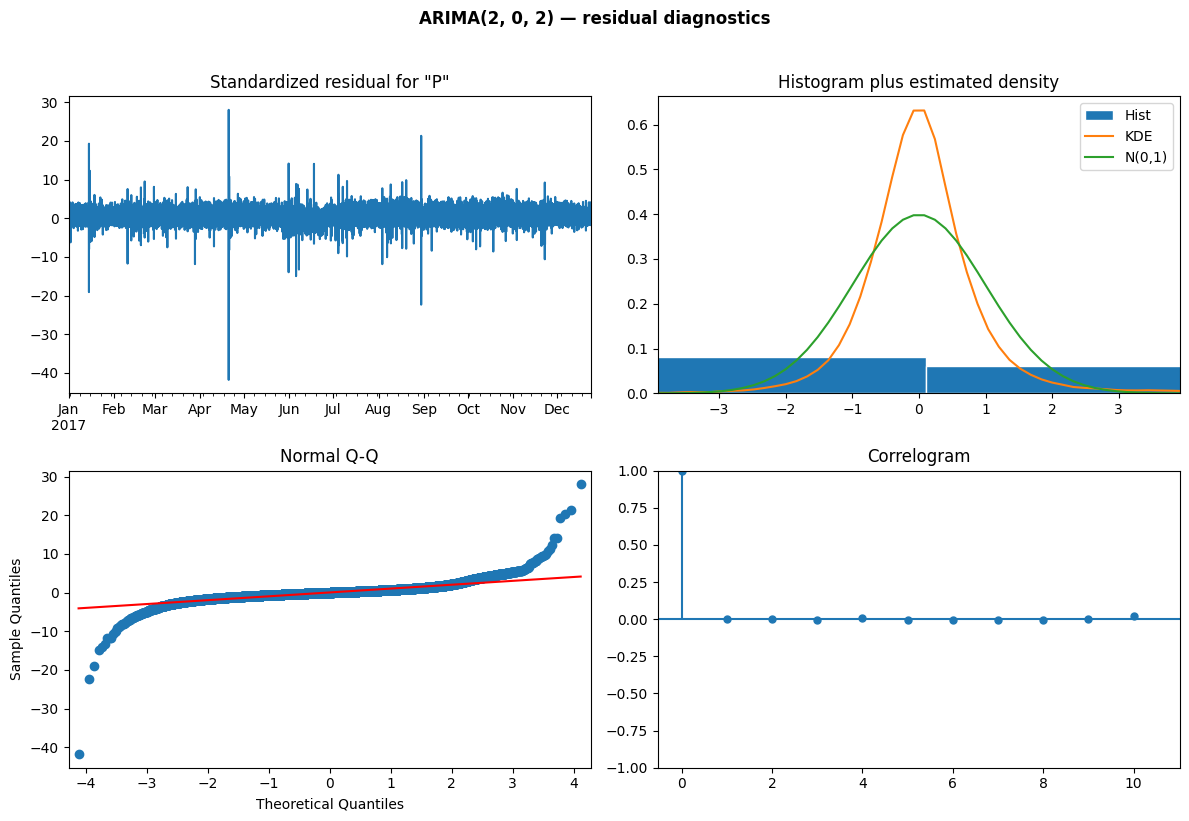

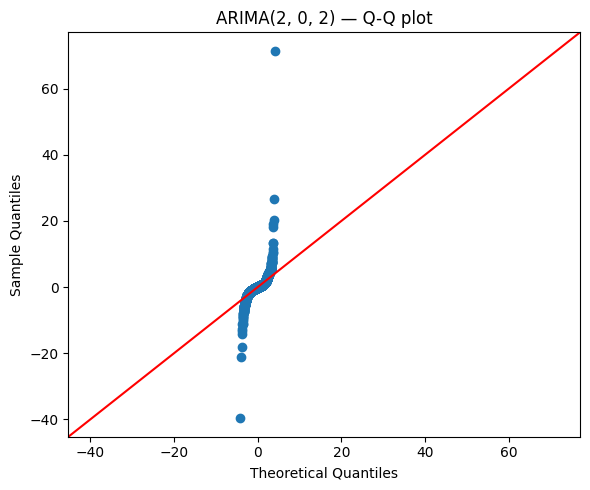

Ljung–Box test on residuals:
       lb_stat  lb_pvalue
10     40.6477        0.0
20     69.6603        0.0
30    264.5724        0.0
50    393.0121        0.0
144  8943.7494        0.0


In [23]:
model_1_d0 = fit_and_diagnose(train, best_order_1_d0, "Combination 1")
model_2_d0 = fit_and_diagnose(train, best_order_2_d0, "Combination 2")

Naïve approach

In [15]:
def naive_seasonal_forecast(model, n_steps, test_index, train_series):
    # ARIMA point forecast (level, no seasonality)
    arima_pred = model.get_forecast(steps=n_steps).predicted_mean.values

    # Time-of-day profile from the last 4 weeks of training
    last_4w = train_series.iloc[-SEASONAL_M * 28:]
    bucket  = last_4w.index.hour * 6 + last_4w.index.minute // 10   # 0..143
    profile = last_4w.groupby(bucket).mean()
    profile_mean = profile.mean()

    # Look up the right bucket for each test timestamp
    test_bucket = test_index.hour * 6 + test_index.minute // 10
    seasonal_adj = profile.reindex(test_bucket).values - profile_mean

    return arima_pred + seasonal_adj


arima_1_pred = naive_seasonal_forecast(model_1, TESTTIMESTEPS, test.index, train)
arima_2_pred = naive_seasonal_forecast(model_2, TESTTIMESTEPS, test.index, train)

d = 0

In [24]:
arima_1_pred_d0 = naive_seasonal_forecast(model_1_d0, TESTTIMESTEPS, test.index, train)
arima_2_pred_d0 = naive_seasonal_forecast(model_2_d0, TESTTIMESTEPS, test.index, train)

MAPE and Baseline

In [16]:
baseline_last = np.full(TESTTIMESTEPS, train.iloc[-1])
baseline_mean = np.full(TESTTIMESTEPS, train.mean())
baseline_naive_se = train.iloc[-TESTTIMESTEPS:].values


def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100


results = {
    "Baseline — Last value": mape(test.values, baseline_last),
    "Baseline — Train mean": mape(test.values, baseline_mean),
    "Baseline — Naïve seasonal (week)": mape(test.values, baseline_naive_se),
    f"ARIMA {best_order_1} + naïve seasonal": mape(test.values, arima_1_pred),
    f"ARIMA {best_order_2} + naïve seasonal": mape(test.values, arima_2_pred),
}

results_df = (pd.DataFrame.from_dict(results, orient="index", columns=["MAPE (%)"])
                .sort_values("MAPE (%)"))
print(results_df.round(2))

                                  MAPE (%)
Baseline — Naïve seasonal (week)      2.05
ARIMA (2, 1, 3) + naïve seasonal     13.84
ARIMA (2, 1, 2) + naïve seasonal     13.88
Baseline — Last value                19.38
Baseline — Train mean                23.15


d = 0

In [25]:
baseline_last = np.full(TESTTIMESTEPS, train.iloc[-1])
baseline_mean = np.full(TESTTIMESTEPS, train.mean())
baseline_naive_se = train.iloc[-TESTTIMESTEPS:].values


def mape(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred) * 100


results = {
    "Baseline — Last value": mape(test.values, baseline_last),
    "Baseline — Train mean": mape(test.values, baseline_mean),
    "Baseline — Naïve seasonal (week)": mape(test.values, baseline_naive_se),
    f"ARIMA {best_order_1} + naïve seasonal": mape(test.values, arima_1_pred_d0),
    f"ARIMA {best_order_2} + naïve seasonal": mape(test.values, arima_2_pred_d0),
}

results_df = (pd.DataFrame.from_dict(results, orient="index", columns=["MAPE (%)"])
                .sort_values("MAPE (%)"))
print(results_df.round(2))

                                  MAPE (%)
Baseline — Naïve seasonal (week)      2.05
Baseline — Last value                19.38
Baseline — Train mean                23.15
ARIMA (2, 0, 2) + naïve seasonal     62.89
ARIMA (3, 0, 3) + naïve seasonal     63.29


Visualization

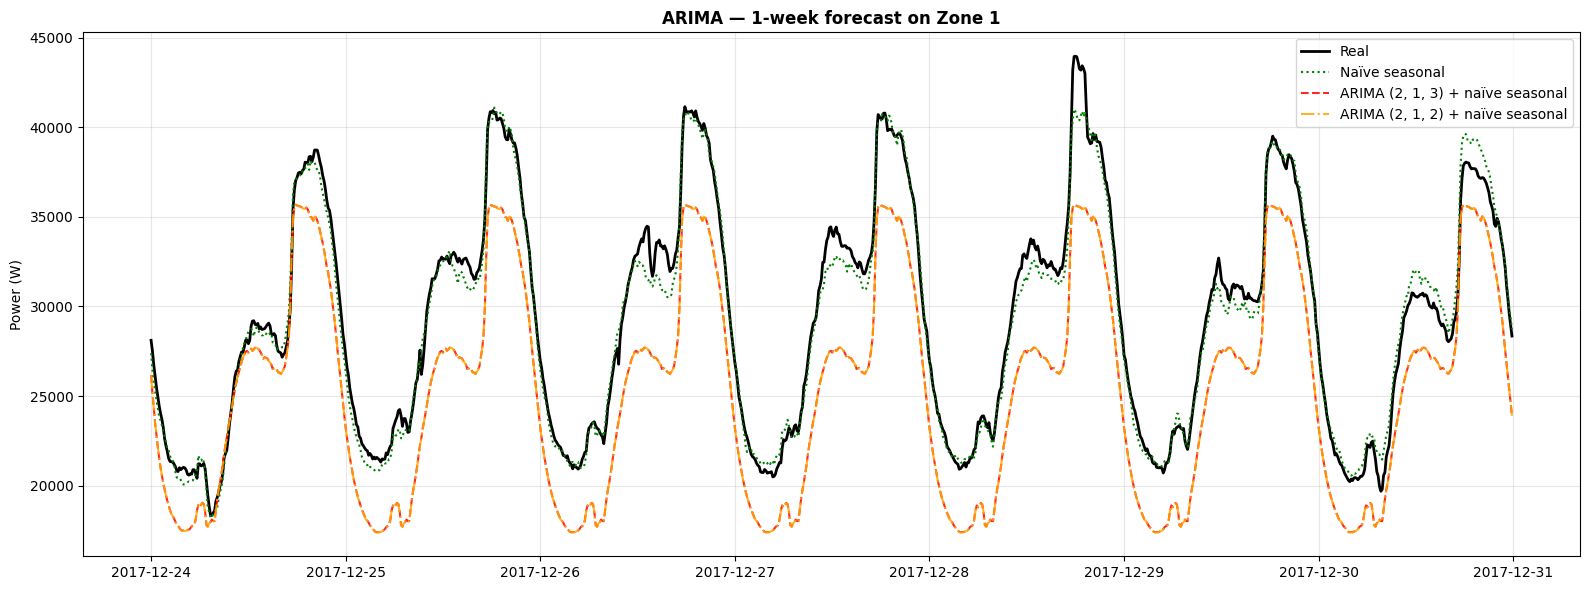

In [17]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test.index, test.values, color="black", linewidth=2, label="Real")
ax.plot(test.index, baseline_naive_se, color="green", linestyle=":", label="Naïve seasonal")
ax.plot(test.index, arima_1_pred, color="red", linestyle="--", alpha=0.85,
        label=f"ARIMA {best_order_1} + naïve seasonal")
ax.plot(test.index, arima_2_pred, color="orange",  linestyle="-.", alpha=0.85,
        label=f"ARIMA {best_order_2} + naïve seasonal")

ax.set_title("ARIMA — 1-week forecast on Zone 1", fontweight="bold")
ax.set_ylabel("Power (W)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

d = 0

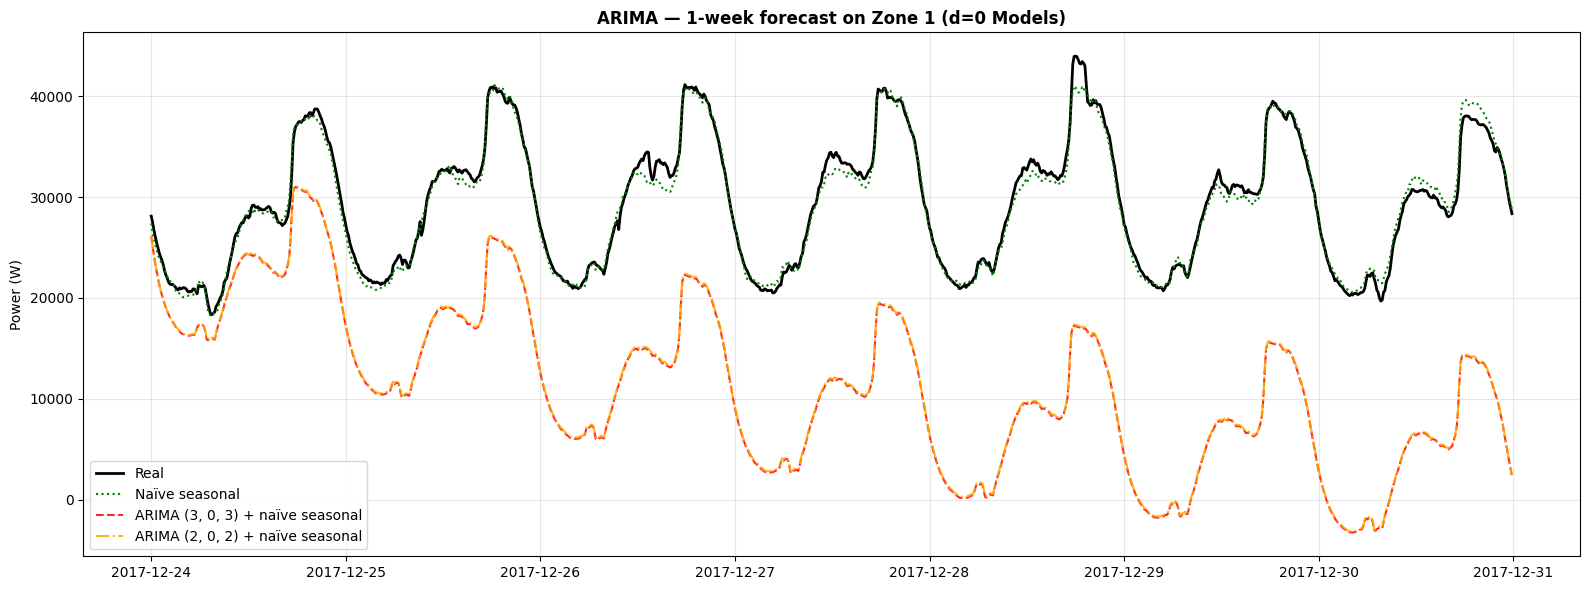

In [26]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test.index, test.values, color="black", linewidth=2, label="Real")
ax.plot(test.index, baseline_naive_se, color="green", linestyle=":", label="Naïve seasonal")

ax.plot(test.index, arima_1_pred_d0, color="red", linestyle="--", alpha=0.85,
        label=f"ARIMA {best_order_1_d0} + naïve seasonal")
ax.plot(test.index, arima_2_pred_d0, color="orange",  linestyle="-.", alpha=0.85,
        label=f"ARIMA {best_order_2_d0} + naïve seasonal")

ax.set_title("ARIMA — 1-week forecast on Zone 1 (d=0 Models)", fontweight="bold")
ax.set_ylabel("Power (W)")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()